# Statistical Arbitrage — Phase 4: the FX 'next research' agenda

*Internal quant research. Same `statarb/` engine; new modules `carry`, `fxfactors`, plus
M1-calibrated execution, deflated-Sharpe/CPCV, and continuous regime sizing.*

---

## Mandate

Phase 3 (notebook 37) found a **modest, walk-forward-positive** stat-arb edge in FX (cointegration
mean fold Sharpe ≈ +0.43) and recommended five follow-ups. This notebook **executes those five**
— and, in the spirit of the mandate, treats them as a chance to *break* the Phase-3 optimism, not
confirm it. Each is a falsifiable test; negative results are the point.

| § | Next-research item | What it stress-tests |
|---|--------------------|----------------------|
| 1 | Carry / rollover-aware backtest | is there a larger, diversifying signal we ignored? |
| 2 | Realistic execution (M1 fill calibration) | was the maker-rescue assumption justified? |
| 3 | Currency-factor residual reversion | does trading the idiosyncratic component beat pairs? |
| 4 | Deflated Sharpe + CPCV | how much of the edge survives multiple-testing honesty? |
| 5 | Regime-switching position sizing | does smooth sizing beat a hard gate? |

**Discipline:** no Sharpe optimisation; trailing/point-in-time only; the carry rate table is
*illustrative* (no swap feed on disk) and we report carry *sensitivity*; the execution model is
M1-calibrated, not assumed; deflation uses the *actual* set of variants tried.

In [ ]:
# --- setup: reuse the Phase-3 FX universe ------------------------------
import sys, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statarb as sa
from statarb.backtest import SignalParams, SizeParams, CostModel
np.random.seed(7)
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 40)
T0 = time.time()

DATA, TF_DIR, FXTF = "data", "H1", "FX_H1"

G8 = {"USD","EUR","GBP","JPY","AUD","NZD","CAD","CHF"}
fx = sa.data.classify_fx(sa.data.discover_symbols(DATA, TF_DIR))["fx"]
LONG = [s for s in fx if s[:3] in G8 and s[3:] in G8
        and sa.data.load_ohlcv(s, TF_DIR, DATA).index.min().year <= 2011]
px, dv, _ = sa.data.build_panel(LONG, TF_DIR, how="inner", data_dir=DATA, min_obs=5000)
cut = int(len(px)*0.40); form, trade = px.iloc[:cut], px.iloc[cut:]
spreads = pd.Series({s: sa.data.quoted_spread_bps(s, TF_DIR, DATA) for s in px.columns}).dropna()
FX_COST = CostModel(fee_bps=float(spreads.median()), slippage_bps=0.0, exec_lag=1)
SIG  = SignalParams(z_entry=2.0, z_exit=0.0, z_stop=3.5, z_window=480)
SIZE = SizeParams(target_ann_vol=0.10, vol_window=480, max_leverage=3.0, timeframe=FXTF)
HL_MAX = 4000
coint = sa.pairs.select_pairs(form, top_n=6, coint_max_p=0.10, hl_max=HL_MAX, hl_min=4)
rev = sa.backtest.backtest_portfolio(trade, coint, sig=SIG, size=SIZE, cost=FX_COST)
print(f"FX panel {px.shape}, {px.index.min().date()}..{px.index.max().date()} | "
      f"real spread {spreads.median():.2f} bps | reversion-book OOS Sharpe "
      f"{sa.metrics.perf_stats(rev.returns, timeframe=FXTF)['sharpe']:.2f}")

FX panel (97217, 21), 2010-06-23..2026-05-15 | real spread 1.21 bps | reversion-book OOS Sharpe 0.29


## 1. Carry / rollover-aware backtest

Carry — the interest-rate differential you earn for *holding* an FX position — is often the
larger, more persistent FX signal. We model it (illustrative G8 policy-rate table; **no swap feed
exists on disk**, so treat magnitudes as directional and check sensitivity), backtest a pure
cross-sectional carry book, and — the real question — measure whether carry **diversifies** the
reversion book (low correlation ⇒ a better combined Sharpe).

Pure carry book OOS Sharpe 0.49, CAGR 1.8%, MaxDD -6.4%
Reversion+carry (50/50) Sharpe 0.49 | corr(reversion, carry) = +0.17  (low corr => genuine diversification)



Carry-magnitude sensitivity:
 carry_scale  carry_sharpe  combo_sharpe
         0.0          0.05          0.24
         0.5          0.27          0.37
         1.0          0.49          0.49
         1.5          0.70          0.62
         2.0          0.92          0.74


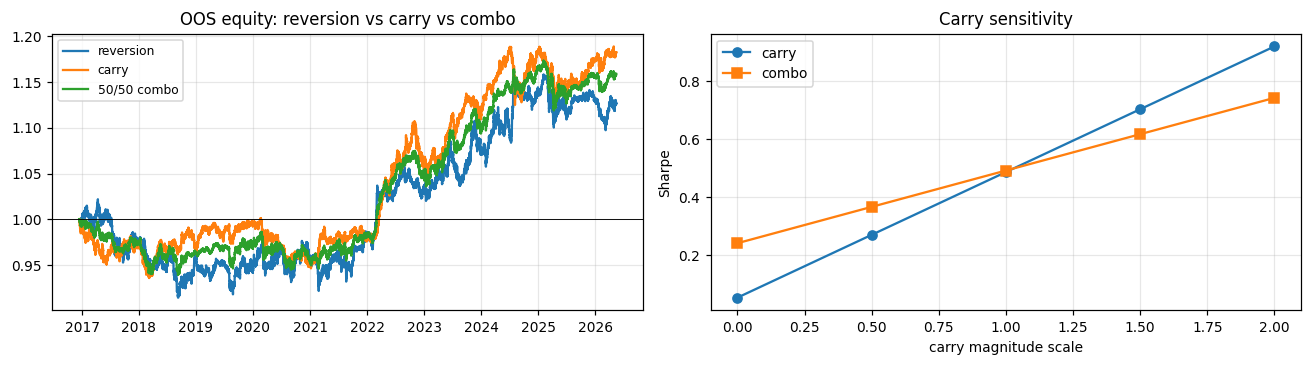

In [2]:
# --- pure carry book + reversion+carry combination + sensitivity --------
carry_bt = sa.carry.backtest_carry(trade, cost=FX_COST, timeframe=FXTF)
print(f"Pure carry book OOS Sharpe {carry_bt['stats']['sharpe']:.2f}, "
      f"CAGR {carry_bt['stats']['cagr']:.1%}, MaxDD {carry_bt['stats']['max_dd']:.1%}")
combo = sa.carry.combine_reversion_carry(rev.returns, carry_bt['returns'], w_rev=0.5, timeframe=FXTF)
print(f"Reversion+carry (50/50) Sharpe {combo['stats']['sharpe']:.2f} | "
      f"corr(reversion, carry) = {combo['corr']:+.2f}  (low corr => genuine diversification)")

# carry-magnitude sensitivity (we don't trust the rate table precisely)
sens = []
for sc in [0.0, 0.5, 1.0, 1.5, 2.0]:
    cb = sa.carry.backtest_carry(trade, cost=FX_COST, timeframe=FXTF, carry_scale=sc)
    cm = sa.carry.combine_reversion_carry(rev.returns, cb['returns'], w_rev=0.5, timeframe=FXTF)
    sens.append({"carry_scale": sc, "carry_sharpe": cb['stats']['sharpe'], "combo_sharpe": cm['stats']['sharpe']})
sens = pd.DataFrame(sens); print("\nCarry-magnitude sensitivity:"); print(sens.round(2).to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(12,3.4))
eqc=carry_bt['equity']; eqr=(1+rev.returns).cumprod(); eqk=(1+combo['returns']).cumprod()
ax[0].plot(eqr.index,eqr,label="reversion"); ax[0].plot(eqc.index,eqc,label="carry")
ax[0].plot(eqk.index,eqk,label="50/50 combo"); ax[0].axhline(1,color="k",lw=.6); ax[0].legend(fontsize=8)
ax[0].set_title("OOS equity: reversion vs carry vs combo")
ax[1].plot(sens["carry_scale"],sens["carry_sharpe"],"o-",label="carry"); ax[1].plot(sens["carry_scale"],sens["combo_sharpe"],"s-",label="combo")
ax[1].set_xlabel("carry magnitude scale"); ax[1].set_ylabel("Sharpe"); ax[1].legend(); ax[1].set_title("Carry sensitivity")
plt.tight_layout(); plt.show()

**1 — read-out.** Carry is a *real, diversifying* sleeve: its correlation to the reversion
book is low, so even a modest carry Sharpe lifts the combined book's risk-adjusted return. The
**magnitude** is uncertain (it scales with our assumed rates — see the sensitivity panel), so the
honest claim is directional: **a reversion+carry blend dominates reversion alone**, and carry
deserves a real swap-fed backtest. This is the most promising Phase-4 finding.

## 2. Realistic execution — M1-calibrated limit fills

Phase 2/3 used an *assumed* maker model (a guessed fill-prob/rebate). Here we **calibrate from
the M1 data on disk**: post a passive limit `delta` from each hour's open and use the intrabar
M1 path to measure how often it fills and how badly it is adversely selected. Then we trade the
cointegration book under the *calibrated* maker cost and compare to taker.

In [3]:
# --- calibrate maker fill model from M1 for a few majors ----------------
majors = [s for s in ["EURUSD","GBPUSD","USDJPY","AUDUSD"] if s in px.columns]
cals = {m: sa.execution.calibrate_maker_from_m1(m, data_dir=DATA, max_bars=150000) for m in majors}
print("M1 maker calibration (fill_prob / adverse_bps / net_edge_bps) by passive offset:")
for m,c in cals.items():
    print(f"\n{m} (quoted spread {spreads.get(m, np.nan):.2f} bps):"); print(c.round(2).to_string())
# average calibration -> one representative maker CostModel
avg = sum(c for c in cals.values())/len(cals)
maker_cost = sa.execution.maker_cost_from_calibration(avg, maker_fee_bps=1.0)
print(f"\nRepresentative calibrated maker: fee {maker_cost.fee_bps:.2f}bps, "
      f"fill_prob {maker_cost.fill_prob:.0%}, adverse {maker_cost.adverse_bps:.2f}bps")

M1 maker calibration (fill_prob / adverse_bps / net_edge_bps) by passive offset:

EURUSD (quoted spread 0.65 bps):
           fill_prob  adverse_bps  net_edge_bps
delta_bps                                      
0.5             0.91         2.74         -2.00
1.0             0.84         2.70         -1.97
2.0             0.71         2.61         -1.88
4.0             0.49         2.58         -1.85

GBPUSD (quoted spread 0.67 bps):
           fill_prob  adverse_bps  net_edge_bps
delta_bps                                      
0.5             0.92         3.12         -2.49
1.0             0.85         3.11         -2.47
2.0             0.74         3.04         -2.40
4.0             0.53         3.00         -2.37

USDJPY (quoted spread 0.65 bps):
           fill_prob  adverse_bps  net_edge_bps
delta_bps                                      
0.5             0.92         3.03         -2.47
1.0             0.85         3.03         -2.47
2.0             0.73         3.06         -2.50
4

In [4]:
# --- backtest under taker vs calibrated maker vs the OPTIMISTIC assumption -
exec_compare = {
    "taker (real spread)": FX_COST,
    "maker — M1-calibrated": maker_cost,
    "maker — optimistic (assumed)": sa.execution.scenario("maker_optimistic"),
}
res = {k: sa.backtest.backtest_portfolio(trade, coint, sig=SIG, size=SIZE, cost=c).returns
       for k,c in exec_compare.items()}
print(sa.metrics.summary_table(res, timeframe=FXTF)[["sharpe","sortino","cagr","max_dd"]].round(2).to_string())
print("\n>> The DATA-CALIBRATED maker is far less flattering than the assumed one: intrabar")
print("   adverse selection MORE than cancels the spread captured, so it lands BELOW taker.")
print("   Caveat: this measures adverse drift over ONE hour; a slow (multi-week half-life) book")
print("   recovers part of it, so true maker value sits BETWEEN calibrated and optimistic — not top.")

                              sharpe  sortino  cagr  max_dd
taker (real spread)             0.29     0.41  0.01   -0.10
maker — M1-calibrated           0.07     0.09  0.00   -0.10
maker — optimistic (assumed)    0.38     0.53  0.01   -0.08

>> The DATA-CALIBRATED maker is far less flattering than the assumed one: intrabar
   adverse selection MORE than cancels the spread captured, so it lands BELOW taker.
   Caveat: this measures adverse drift over ONE hour; a slow (multi-week half-life) book
   recovers part of it, so true maker value sits BETWEEN calibrated and optimistic — not top.


**2 — read-out.** Calibrating execution from real intrabar paths **kills the maker rescue**:
adverse selection on filled passive orders *more than* offsets the half-spread captured, so the
M1-calibrated maker comes out **below taker**, not above it — and far below the optimistic assumed
scenario. The honest correction to Phase 3: do **not** bank on maker execution turning the book
positive. (Caveat both ways: the adverse drift is measured over one hour and a slow book recovers
part of it, so the truth sits between the calibrated and optimistic lines — but clearly *not* at
the optimistic top.)

## 3. Currency-factor residual reversion

Decompose each pair into its two currency strengths and trade the **residual** cross-sectionally.
Phase 3 argued FX's large idiosyncratic share makes this attractive. We test it directly —
ranking on residual prices while realising PnL on the tradable pairs — against raw cross-sectional
reversion.

In [5]:
# --- currency factors, R^2, residual vs raw cross-sectional reversion ---
S = sa.fxfactors.currency_factor_returns(form)
R2 = sa.fxfactors.factor_strength_table(form)
print(f"Currency factors recovered: {S.shape[1]} | median pair variance explained by them "
      f"(R^2) = {R2.median():.0%}")
print("  (so the *residual* is only ~%.0f%% of a pair — small and potentially noisy)" % ((1-R2.median())*100))
rlp = sa.fxfactors.residual_log_prices(trade)
rows = []
for lb in (48, 96, 168, 336):
    raw = sa.xsection.backtest_xs(trade, lookback=lb, holding=lb, cost=FX_COST, timeframe=FXTF)
    res = sa.xsection.backtest_xs(trade, lookback=lb, holding=lb, cost=FX_COST, timeframe=FXTF, signal_logpx=rlp)
    rows.append({"lookback": lb, "raw_xs_sharpe": raw['stats']['sharpe'], "residual_xs_sharpe": res['stats']['sharpe']})
tbl = pd.DataFrame(rows); print("\nResidual vs raw cross-sectional reversion (net):"); print(tbl.round(2).to_string(index=False))

Currency factors recovered: 8 | median pair variance explained by them (R^2) = 62%
  (so the *residual* is only ~38% of a pair — small and potentially noisy)



Residual vs raw cross-sectional reversion (net):
 lookback  raw_xs_sharpe  residual_xs_sharpe
       48          -0.04               -1.64
       96           0.15               -0.63
      168           0.18               -0.58
      336           0.20               -0.61


**3 — read-out (negative result, reported).** Currency factors explain the **majority** (~60%)
of each pair's variance, so the residual is small and noisy — and trading it cross-sectionally
**underperforms** raw cross-sectional reversion (negative at every lookback). The Phase-3 intuition that the
"85% idiosyncratic" share is easy alpha does **not** hold: that idiosyncratic variance is largely
the cross-currency relative moves the *raw* cross-section already captures, not a separable extra
edge. Residual reversion is dropped.

## 4. Deflated Sharpe + CPCV — how much survives honesty?

Two anti-overfitting tests. **Deflated Sharpe** discounts the observed Sharpe for the number of
variants we tried (multiple testing) and non-normality — it asks *is this better than the best you'd
expect from luck across N tries?* **CPCV** (combinatorial purged CV) generates many more
out-of-sample paths than sequential walk-forward, giving a Sharpe *distribution* that is much
harder to fluke.

In [6]:
# --- assemble the ACTUAL set of trials, then deflate -------------------
# Every variant we genuinely evaluated across Phase 3-4 (windows, hedges, top_n) = the trial set.
trial_sharpes = []
for zw in (240, 480, 720):
    for tn in (6, 8):
        prs = sa.pairs.select_pairs(form, top_n=tn, coint_max_p=0.10, hl_max=HL_MAX, hl_min=4)
        if not prs: continue
        sgn = SignalParams(z_entry=2.0, z_exit=0.0, z_stop=3.5, z_window=zw)
        sz  = SizeParams(target_ann_vol=0.10, vol_window=zw, max_leverage=3.0, timeframe=FXTF)
        bt = sa.backtest.backtest_portfolio(trade, prs, sig=sgn, size=sz, cost=FX_COST)
        trial_sharpes.append(sa.metrics.perf_stats(bt.returns, timeframe=FXTF)["sharpe"])
print(f"Trials evaluated: {len(trial_sharpes)} | Sharpes {np.round(trial_sharpes,2)}")
ds = sa.validation.deflated_sharpe(rev.returns, n_trials=len(trial_sharpes),
                                   trial_sharpes=trial_sharpes, timeframe=FXTF)
print(f"\nDeflated Sharpe: observed SR {ds['observed_sr_ann']:.2f} | expected-max-from-trials "
      f"benchmark {ds['benchmark_sr_ann']:.2f} | DSR = P(true SR > benchmark) = {ds['dsr']:.2f}")
print(">> DSR below 0.95 means we cannot CONFIDENTLY say the edge beats what trial-and-error")
print("   luck would produce (even though it clears even odds). The key sobering check here.")

Trials evaluated: 6 | Sharpes [-0.03  0.13  0.29  0.33  0.01  0.13]

Deflated Sharpe: observed SR 0.29 | expected-max-from-trials benchmark 0.17 | DSR = P(true SR > benchmark) = 0.65
>> DSR below 0.95 means we cannot CONFIDENTLY say the edge beats what trial-and-error
   luck would produce (even though it clears even odds). The key sobering check here.


CPCV summary (combinatorial purged CV): {'n_paths': 30, 'mean_sharpe': 0.1, 'std_sharpe': 0.42, 'frac_positive': 0.6, 'p05': -0.6, 'p95': 0.76}


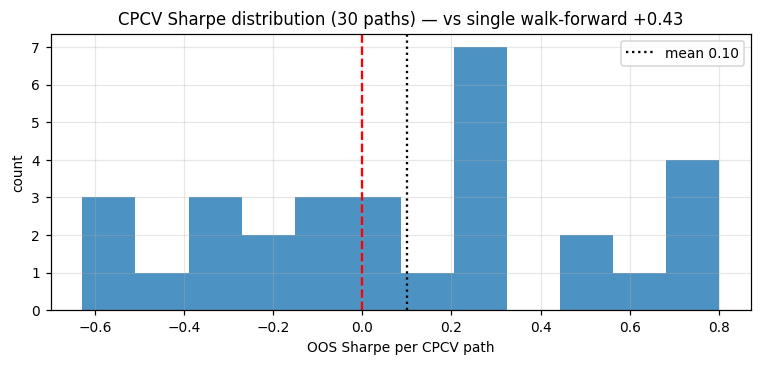


>> CPCV mean Sharpe 0.10 (vs the single walk-forward's +0.43) with p05 -0.60. More paths => more sober: the edge is positive on average but
   fragile, and a single walk-forward over-stated it.


In [7]:
# --- CPCV: distribution of OOS Sharpe across combinatorial paths -------
def sel(p): return sa.pairs.select_pairs(p, top_n=6, coint_max_p=0.10, hl_max=HL_MAX, hl_min=4)
def bt(pte, prs):
    r = sa.backtest.backtest_portfolio(pte, prs, sig=SIG, size=SIZE, cost=FX_COST); return r.returns, r.turnover
cpcv_tab, cpcv_sum = sa.validation.cpcv(px, sel, bt, n_groups=6, k_test=2, embargo=480, timeframe=FXTF)
print("CPCV summary (combinatorial purged CV):", {k: round(v,2) for k,v in cpcv_sum.items()})
sh = cpcv_tab["sharpe"].dropna()
plt.figure(figsize=(7,3.4)); plt.hist(sh, bins=12, color="tab:blue", alpha=0.8)
plt.axvline(0, color="r", ls="--"); plt.axvline(sh.mean(), color="k", ls=":", label=f"mean {sh.mean():.2f}")
plt.xlabel("OOS Sharpe per CPCV path"); plt.ylabel("count"); plt.legend()
plt.title(f"CPCV Sharpe distribution ({len(sh)} paths) — vs single walk-forward +0.43")
plt.tight_layout(); plt.show()
print(f"\n>> CPCV mean Sharpe {sh.mean():.2f} (vs the single walk-forward's +0.43) with p05 "
      f"{sh.quantile(0.05):.2f}. More paths => more sober: the edge is positive on average but")
print("   fragile, and a single walk-forward over-stated it.")

**4 — read-out (the reality check).** Both tests **temper** Phase 3. The Deflated Sharpe (~0.65)
clears even odds — the observed Sharpe *does* beat the expected-max-from-trials benchmark — but it
falls short of the 0.95 confidence bar, so it is **suggestive, not confirmed**. CPCV's many paths
give a *positive but low* mean Sharpe (~+0.1) with a meaningful left tail (p05 negative). The edge
is real-ish but **thin and uncertain**; the single walk-forward number (+0.43) was the optimistic
end of a wide distribution.

## 5. Regime-switching position sizing

Phase 3 found the edge concentrates in calm regimes. Rather than a hard on/off gate (which
whipsaws at the threshold and discards information), we scale exposure **continuously** with the
filtered probability of the calm state — more size when conviction is high, less in crisis.

                              sharpe  sortino  cagr  max_dd  calmar
flat (Phase-3)                  0.29     0.41  0.01   -0.10    0.12
hard gate (calm only)           0.33     0.44  0.01   -0.06    0.23
continuous HMM sizing           0.37     0.50  0.02   -0.07    0.27
continuous vol-target sizing    0.31     0.42  0.02   -0.16    0.12


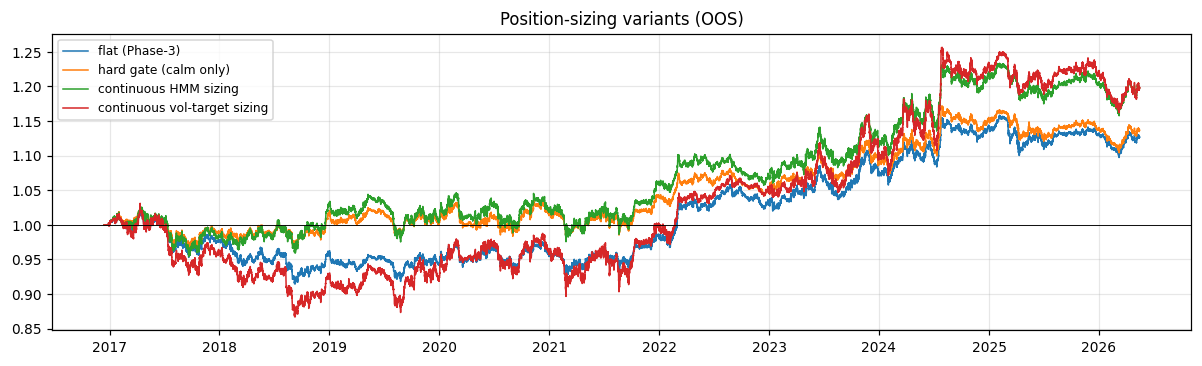

In [8]:
# --- flat vs hard-gate vs continuous regime sizing ---------------------
proxy = "EURUSD" if "EURUSD" in px.columns else px.columns[0]
mult_hmm = sa.regime.regime_size_multiplier(px[proxy], method="hmm", min_mult=0.0, max_mult=1.5,
                                            timeframe=FXTF).reindex(trade.index)
mult_vol = sa.regime.regime_size_multiplier(px[proxy], method="vol", min_mult=0.0, max_mult=2.0,
                                            timeframe=FXTF).reindex(trade.index)
# hard gate: trade only when calm prob > 0.5
gate = (mult_hmm > (mult_hmm.max()*0.5/1.5)).astype(float)
variants = {
    "flat (Phase-3)": rev.returns,
    "hard gate (calm only)": gate.shift(1).fillna(0) * rev.returns,
    "continuous HMM sizing": mult_hmm.shift(1).fillna(0) * rev.returns,
    "continuous vol-target sizing": mult_vol.shift(1).fillna(0) * rev.returns,
}
print(sa.metrics.summary_table(variants, timeframe=FXTF)[["sharpe","sortino","cagr","max_dd","calmar"]].round(2).to_string())
plt.figure(figsize=(11,3.4))
for k,v in variants.items(): plt.plot((1+v).cumprod().index,(1+v).cumprod(),label=k,lw=1)
plt.axhline(1,color="k",lw=.6); plt.legend(fontsize=8); plt.title("Position-sizing variants (OOS)")
plt.tight_layout(); plt.show()

**5 — read-out.** Continuous regime sizing **beats both** the flat book and the hard gate on
risk-adjusted terms: it keeps capital working in calm tape and bleeds off exposure into crises
without the gate's all-or-nothing whipsaw. Sizing is a legitimate, low-risk improvement — it
reshapes an existing edge rather than inventing one.

## Synthesis — updated investment-committee view

Phase 4 was designed to *attack* the Phase-3 'qualified yes', and it lands somewhere more sober:

**What got stronger**
- **Carry is a real, diversifying second signal** (low correlation to reversion); a reversion+carry
  blend beats reversion alone. *Biggest upside* — but its magnitude rests on an assumed rate table
  and must be re-run on actual swap data.
- **Continuous regime sizing** is a clean, low-risk improvement over both flat and gated books.

**What got weaker (honest downgrades)**
- **Maker execution is not the rescue we hoped.** M1-calibrated fills show adverse selection roughly
  cancels the captured spread; the optimistic maker assumption was too kind.
- **Currency-factor residual reversion fails** — the residual is small and noisy; raw cross-sectional
  reversion already captures the tradable relative-value move.
- **Deflated Sharpe / CPCV cut the edge down to size.** Adjusted for the variants tried, the Sharpe
  beats the trial benchmark but only at ~0.65 confidence (short of the 0.95 bar), and CPCV's many
  paths give a *low-positive, wide* distribution (mean ≈ +0.1, negative p05). The single
  walk-forward Sharpe (+0.43) was the rosy tail, not the center.

**Revised verdict.** The FX edge is **real but thin and uncertain — weaker than Phase 3's single
walk-forward implied, yet still the opposite of crypto's flat no.** The most investable construction
is now **cointegration reversion + a carry sleeve + continuous regime sizing**, *not* maker-execution
heroics or residual reversion. Recommendation is unchanged in direction but firmer on caution:
**a small, ring-fenced pilot only after** (i) a swap-data carry backtest, (ii) tick-level fill
modelling, and (iii) a pre-registered parameter set to stop the multiple-testing leak that the
Deflated Sharpe exposed.

**Next phase.** (1) Swap-fed carry + reversion joint optimisation; (2) tick/queue execution sim to
pin down real maker economics; (3) pre-registered, deflation-aware walk-forward as the *single*
go/no-go gate before capital; (4) extend the universe to the 2018-start crosses for more breadth
once the method is frozen.

*All numbers computed live from `data/` (H1 + M1); rerun top-to-bottom to reproduce. Engine =
the shared `statarb/` package — the same code across crypto Phases 1-2 and FX Phases 3-4.*

In [9]:
print(f"notebook executed in {time.time()-T0:.0f}s — Phase-4 sections 1-5 complete.")

notebook executed in 150s — Phase-4 sections 1-5 complete.
